In [1]:
from google.colab import files
uploaded = files.upload()   # choose netflix-price-study.zip

Saving netflix-price-study.zip to netflix-price-study.zip


In [2]:
!unzip -q -o netflix-price-study.zip
%cd netflix-price-study
!ls

/content/netflix-price-study
config.yaml  MAINTENANCE_LOG.md  outputs   README.md  requirements.txt	src
data	     monitoring		 pipeline  registry   scripts		tests


In [3]:
!pip install -q -r requirements.txt

In [4]:
!python -m pytest -q

.........                                                                [100%]
9 passed in 4.95s


In [5]:
!python -m pipeline.run

20261007T023440Z-live-2026Q2: 0 alert(s)


# Results summary (generated by pipeline/run.py - do not edit)

- Event: UCAN price increase, 2022Q1. Post window: 2022Q1 to 2022Q4.
- Realised price (ARM) change: +9.5% (list prices +11.0%).
- Effect on membership growth: -0.14 pp per quarter (95% CI -1.17 to +0.90, permutation p = 0.82).
- Donor weights: EMEA 0.13, LATAM 0.02, APAC 0.14; leave-one-out pre-period RMSE 1.10 pp.
- Elasticity, first 2 quarters: -0.17 (95% CI -0.50 to +0.16); membership base -1.6% vs counterfactual.
- Elasticity, first 4 quarters: -0.06 (95% CI -0.49 to +0.38); membership base -0.6% vs counterfactual.
- Incremental UCAN revenue over the post window: $842M (+6.4%), range $564M to $1,114M.
- Contribution margin used (2022, company-wide): 31.4%.
- Incremental contribution at 90% flow-through: $758M; payback quarter: 2022Q1.

| Baseline monthly churn (assumed) | LTV before | LTV after (point) | LTV after (pessimistic) |
|---|---|---|---|
| 1.5% | $203 | $254 | $221 |
| 2.0% | $167 | $209 | $186 |
| 2.5% | $142 | $178 | $161 |
| 3.5% | $109 | $137 | $127 |

- Break-even: LTV is unchanged only if monthly churn rises by 0.76 pp (from 2.0% baseline).
- Company-wide CAC payback (2022, gross adds assumed): $40 per gross add, 11.0 months.


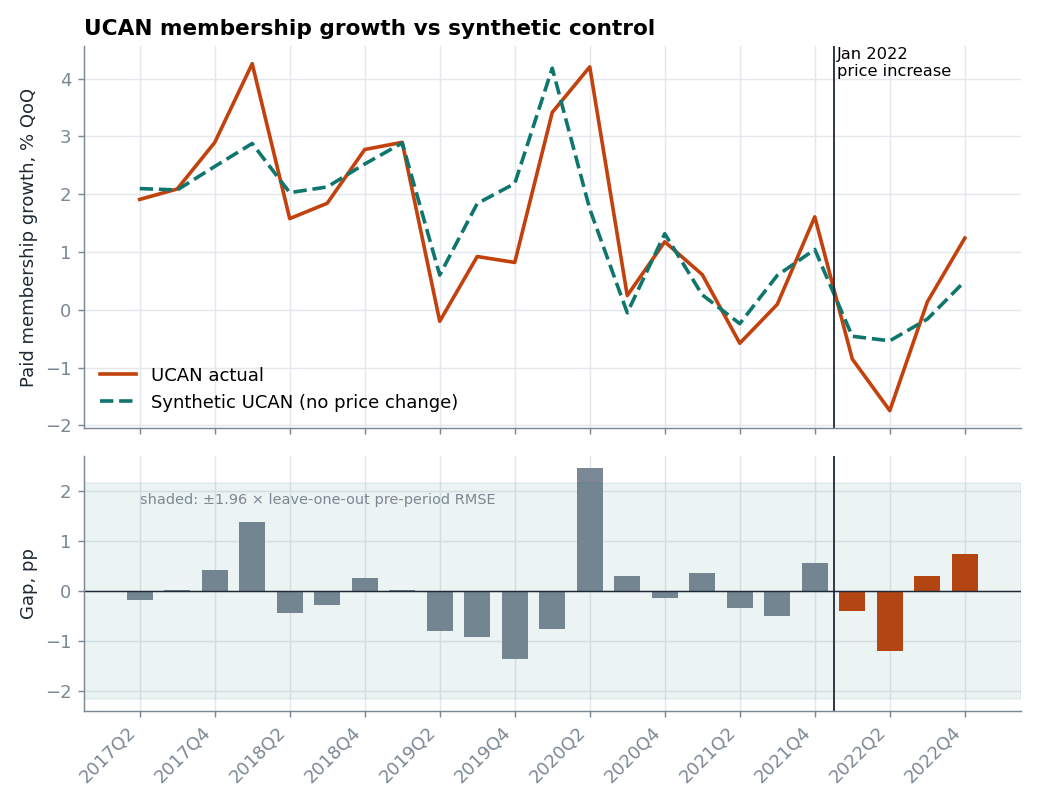

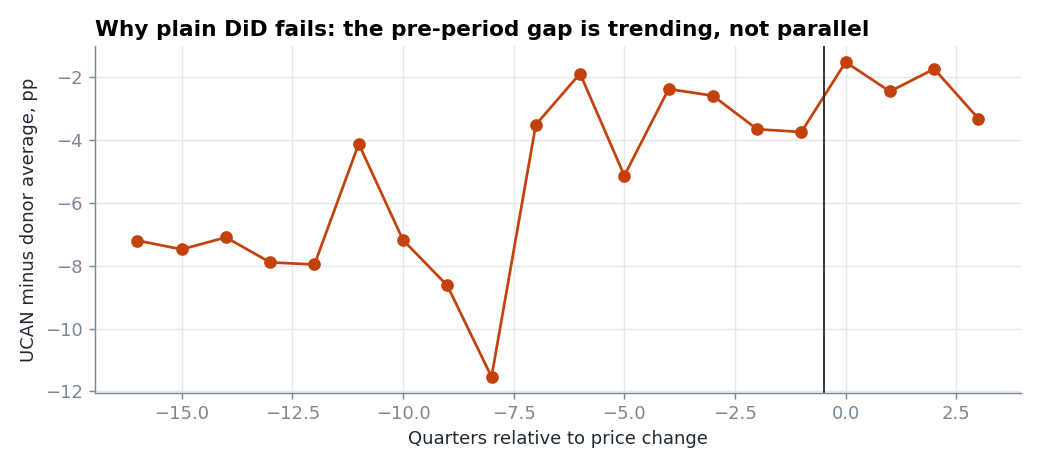

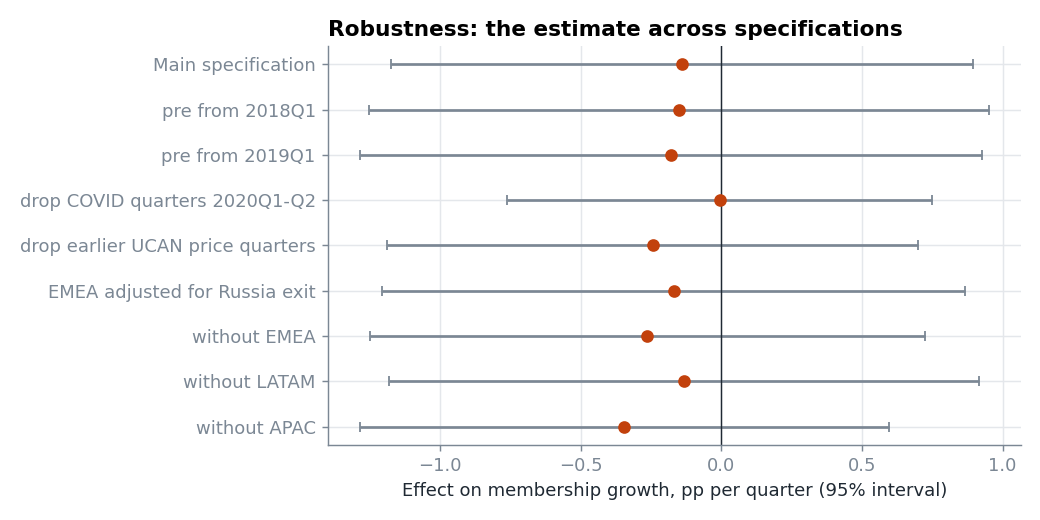

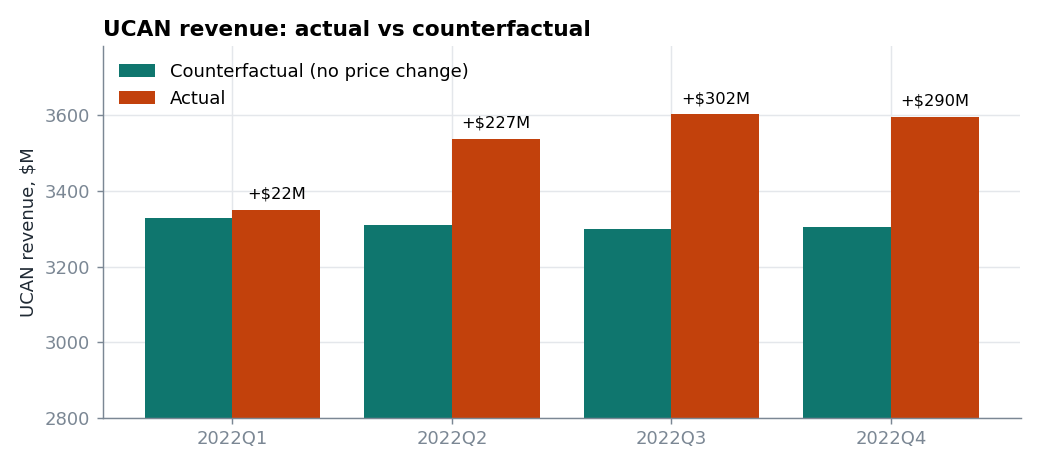

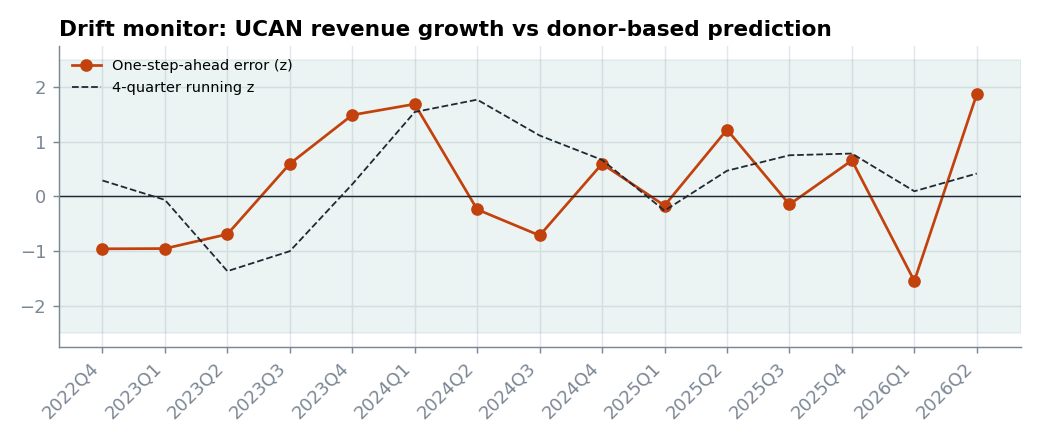

In [6]:
from IPython.display import Markdown, Image, display
display(Markdown(open("outputs/RESULTS.md").read()))
for f in ["synthetic_control", "did_pretrend", "spec_curve", "revenue", "drift_monitor"]:
    display(Image(f"outputs/figures/{f}.png", width=750))

In [7]:
import pandas as pd
display(pd.read_csv("data/raw/netflix_regional_quarterly.csv").query("region == 'UCAN'").tail(12))
display(pd.read_csv("registry/runs.csv").tail(3))

,region,quarter,revenue_musd,paid_memberships_m,paid_net_adds_m,arm_usd,arm_fx_neutral_yoy_pct,source_url
26,UCAN,2023Q3,3735.0,77.32,1.75,16.29,0.0,https://www.sec.gov/Archives/edgar/data/106528...
27,UCAN,2023Q4,3931.0,80.13,2.81,16.64,3.0,https://www.sec.gov/Archives/edgar/data/106528...
28,UCAN,2024Q1,4224.0,82.66,2.53,17.30,7.0,https://www.sec.gov/Archives/edgar/data/106528...
29,UCAN,2024Q2,4296.0,84.11,1.45,17.17,7.0,https://www.sec.gov/Archives/edgar/data/106528...
30,UCAN,2024Q3,4322.0,84.80,0.69,17.06,5.0,https://www.sec.gov/Archives/edgar/data/106528...
31,UCAN,2024Q4,4517.0,89.63,4.82,17.26,4.0,https://www.sec.gov/Archives/edgar/data/106528...
32,UCAN,2025Q1,4617.0,NaN,NaN,NaN,NaN,https://www.sec.gov/Archives/edgar/data/106528...
33,UCAN,2025Q2,4929.0,NaN,NaN,NaN,NaN,https://www.sec.gov/Archives/edgar/data/106528...
34,UCAN,2025Q3,5072.0,NaN,NaN,NaN,NaN,https://www.sec.gov/Archives/edgar/data/106528...
35,UCAN,2025Q4,5339.0,NaN,NaN,NaN,NaN,https://www.sec.gov/Archives/edgar/data/106528...


,run_id,run_utc,mode,as_of_quarter,model_version,code_sha,data_sha,study_post_n,study_tau,study_se,elasticity_4q,incremental_revenue_musd,monitor_z,running_z_4q,monitor_weights,n_alerts,alert_types
13,20261007T020758Z-backfill-2026Q1,2026-10-07T02:07:58+00:00,backfill,2026Q1,1.0.0,nogit,41e3b43fe58d,4,-0.139284,0.528291,-0.058678,841.69,-1.5471,0.0961,"{""EMEA"": 0.4729, ""LATAM"": 0.0, ""APAC"": 0.0}",0,NaN
14,20261007T020800Z-live-2026Q2,2026-10-07T02:08:00+00:00,live,2026Q2,1.0.0,nogit,41e3b43fe58d,4,-0.139284,0.528291,-0.058678,841.69,1.8736,0.4208,"{""EMEA"": 1.35, ""LATAM"": 0.0, ""APAC"": 0.0}",1,model_drift
15,20261007T023440Z-live-2026Q2,2026-10-07T02:34:40+00:00,live,2026Q2,1.0.0,nogit,41e3b43fe58d,4,-0.139284,0.528291,-0.058678,841.69,1.8736,0.4208,"{""EMEA"": 1.35, ""LATAM"": 0.0, ""APAC"": 0.0}",0,NaN
